In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sgp4.api import Satrec, jday
from datetime import datetime, timezone, timedelta
import math

# Load TLE file
with open('starlink.tle') as f:
    lines = f.readlines()

# Load first 100 satellites (enough for good coverage analysis)
satellites = []
for i in range(0, min(3000, len(lines) - 2), 3):
    try:
        name = lines[i].strip()
        line1 = lines[i+1].strip()
        line2 = lines[i+2].strip()
        sat = Satrec.twoline2rv(line1, line2)
        satellites.append((name, sat))
    except:
        continue

# Manta, Ecuador ground station
GROUND_LAT = -0.9677   # degrees (Manta, Ecuador)
GROUND_LON = -80.7089  # degrees (Manta, Ecuador)
GROUND_ALT = 0.006   # km above sea level (approx.)

def eci_to_latlon(r, t):
    x, y, z = r
    lon = math.degrees(math.atan2(y, x)) # finds angle in the xy plane
    lat = math.degrees(math.asin(z / math.sqrt(x**2 + y**2 + z**2))) #
    return lat, lon

print(f"Loaded {len(satellites)} satellites")
print("Ready for coverage analysis")

Loaded 1000 satellites
Ready for coverage analysis


In [2]:
# Generate 24 hours of time steps, every 60 seconds
now = datetime.now(timezone.utc).replace(hour=0, minute=0, second=0, microsecond=0)
time_steps = [now + timedelta(seconds=60*i) for i in range(1440)]

def elevation_angle(sat_lat, sat_lon, sat_alt_km, gnd_lat, gnd_lon):
    """Calculate elevation angle of satellite from ground station in degrees."""
    # Convert to radians
    sl = math.radians(sat_lat)
    so = math.radians(sat_lon)
    gl = math.radians(gnd_lat)
    go = math.radians(gnd_lon)
    
    # Earth radius
    Re = 6371.0
    
    # Central angle between ground and satellite ground track
    cos_central = (math.sin(gl) * math.sin(sl) + 
                   math.cos(gl) * math.cos(sl) * math.cos(so - go))
    cos_central = max(-1, min(1, cos_central))
    central_angle = math.acos(cos_central)
    
    # Elevation angle
    cos_el = math.sin(central_angle) / math.sqrt(
        1 + (Re/(Re + sat_alt_km))**2 - 
        2*(Re/(Re + sat_alt_km))*math.cos(central_angle))
    
    el = math.degrees(math.atan2(
        math.cos(central_angle) - (Re/(Re + sat_alt_km)),
        math.sin(central_angle)))
    
    return el

# Build visibility matrix: rows=satellites, cols=time steps
print("Computing visibility matrix — this takes about 30 seconds...")
visibility = np.zeros((len(satellites), len(time_steps)))

for si, (name, sat) in enumerate(satellites):
    for ti, t in enumerate(time_steps):
        jd, fr = jday(t.year, t.month, t.day, t.hour, t.minute, t.second)
        e, r, v = sat.sgp4(jd, fr)
        if e == 0:
            lat, lon = eci_to_latlon(r, t)
            alt_km = math.sqrt(r[0]**2 + r[1]**2 + r[2]**2) - 6371.0
            el = elevation_angle(lat, lon, alt_km, GROUND_LAT, GROUND_LON)
            if el > 25:  # visible if above 25 degrees elevation
                visibility[si, ti] = 1

print(f"Done. Visibility matrix shape: {visibility.shape}")
print(f"Total visible satellite-minutes: {int(visibility.sum())}")

Computing visibility matrix — this takes about 30 seconds...
Done. Visibility matrix shape: (1000, 1440)
Total visible satellite-minutes: 2597


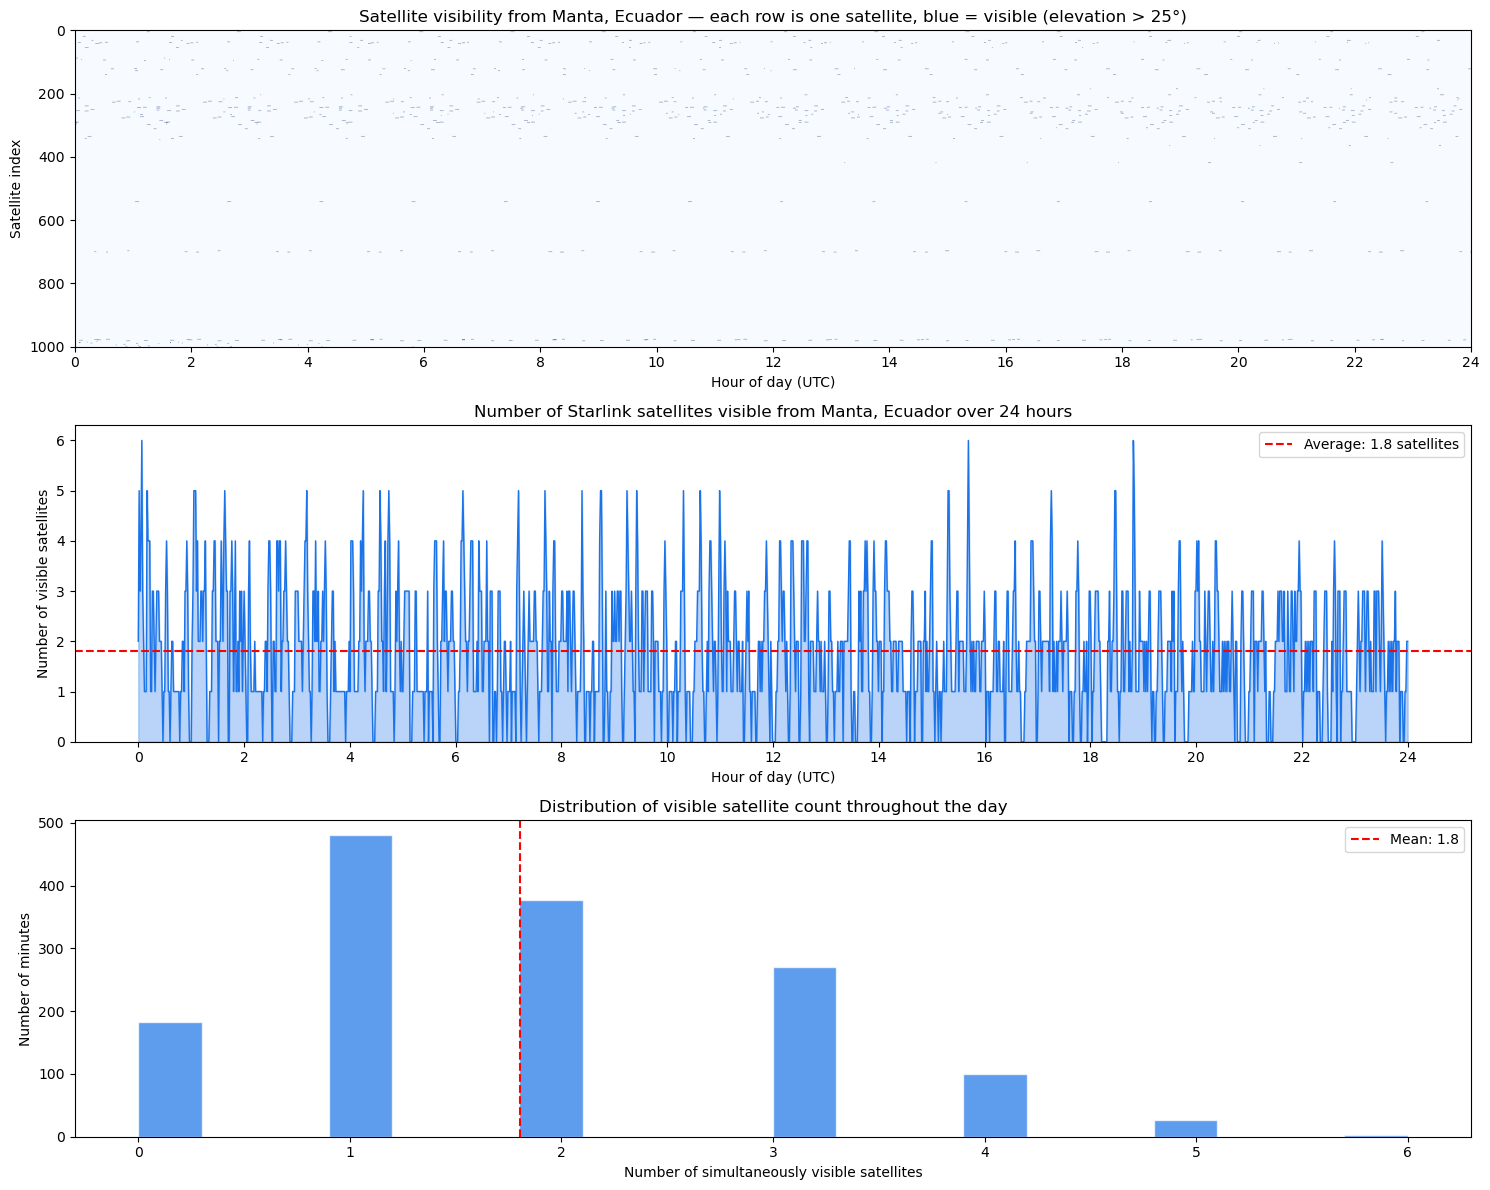

Average visible satellites: 1.8
Maximum visible satellites: 6
Minimum visible satellites: 0
Minutes with zero coverage: 183


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Plot 1: Visibility heatmap
ax1 = axes[0]
ax1.imshow(visibility, aspect='auto', cmap='Blues',
           extent=[0, 24, len(satellites), 0])
ax1.set_xlabel('Hour of day (UTC)')
ax1.set_ylabel('Satellite index')
ax1.set_title('Satellite visibility from Manta, Ecuador — each row is one satellite, blue = visible (elevation > 25°)')
ax1.set_xticks(range(0, 25, 2))

# Plot 2: Number of visible satellites over time
visible_count = visibility.sum(axis=0)
hours = np.linspace(0, 24, 1440)

ax2 = axes[1]
ax2.plot(hours, visible_count, color='#1a73e8', linewidth=1)
ax2.fill_between(hours, visible_count, alpha=0.3, color='#1a73e8')
ax2.axhline(y=visible_count.mean(), color='red', linestyle='--', 
            label=f'Average: {visible_count.mean():.1f} satellites')
ax2.set_xlabel('Hour of day (UTC)')
ax2.set_ylabel('Number of visible satellites')
ax2.set_title('Number of Starlink satellites visible from Manta, Ecuador over 24 hours')
ax2.set_xticks(range(0, 25, 2))
ax2.legend()
ax2.set_ylim(bottom=0)

# Plot 3: Histogram of visible satellite counts
ax3 = axes[2]
ax3.hist(visible_count, bins=20, color='#1a73e8', alpha=0.7, edgecolor='white')
ax3.axvline(x=visible_count.mean(), color='red', linestyle='--',
            label=f'Mean: {visible_count.mean():.1f}')
ax3.set_xlabel('Number of simultaneously visible satellites')
ax3.set_ylabel('Number of minutes')
ax3.set_title('Distribution of visible satellite count throughout the day')
ax3.legend()

plt.tight_layout()
plt.savefig('visibility_timeline.png', dpi=150)
plt.show()

# Print summary stats
print(f"Average visible satellites: {visible_count.mean():.1f}")
print(f"Maximum visible satellites: {int(visible_count.max())}")
print(f"Minimum visible satellites: {int(visible_count.min())}")
print(f"Minutes with zero coverage: {int((visible_count == 0).sum())}")

## Computation scaling observation

Visibility matrix for 1000 satellites × 1440 time steps = 1.44 million 
elevation angle calculations. Computation time is roughly 3-5 minutes on 
a MacBook. A production system would use spatial indexing (e.g. a k-d tree) 
to only check satellites within a bounding box around the ground station, 
reducing computation by ~90%.

Minimum elevation cutoff set to 25° based on standard satellite communication 
practice — below 25° the atmospheric path length becomes too long and signal 
quality degrades significantly.

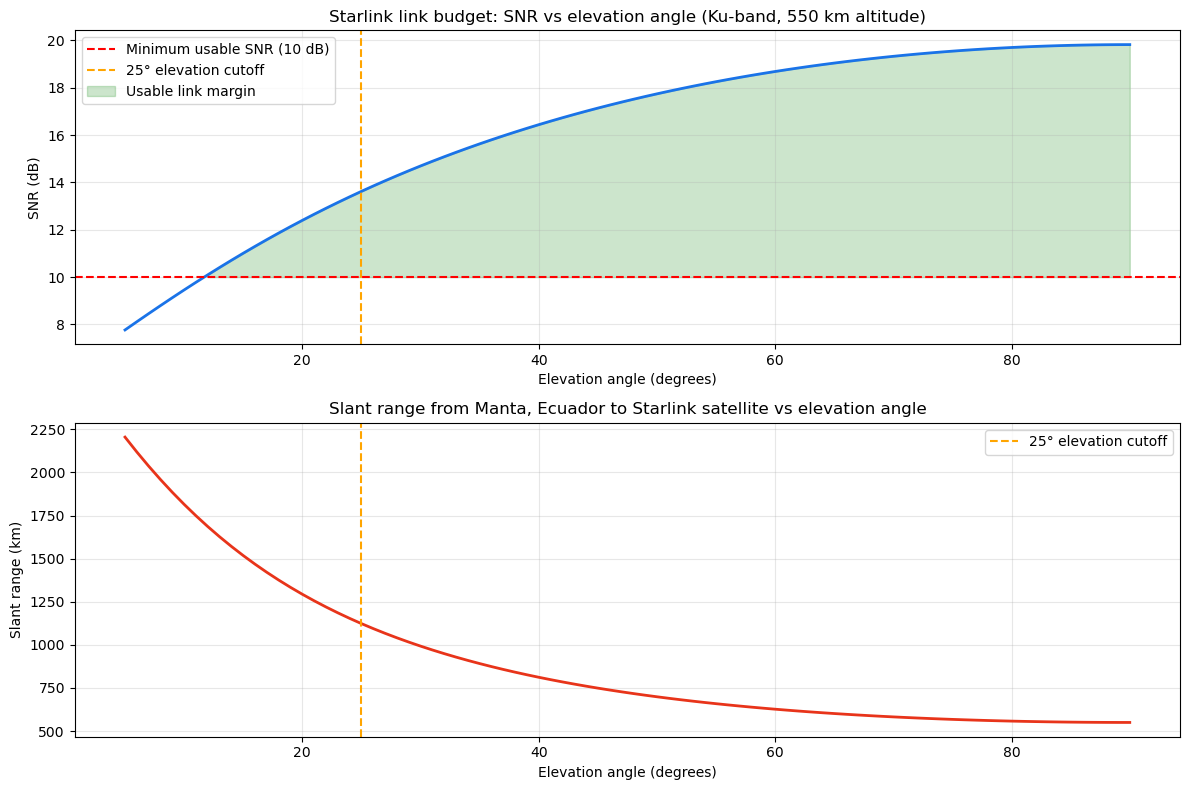

SNR at 25° elevation: 13.6 dB
SNR at 90° elevation: 19.8 dB
SNR improvement from 25° to 90°: 6.2 dB


In [4]:
# Find a satellite pass with high elevation over Manta
# and plot SNR vs elevation angle through the pass

def compute_snr(elevation_deg):
    """Simple link budget: SNR as function of elevation angle."""
    if elevation_deg <= 0:
        return None
    
    # Starlink parameters
    eirp_dbw = 37.0          # satellite transmit power
    freq_hz = 14e9           # Ku-band downlink ~14 GHz
    c = 3e8
    wavelength = c / freq_hz
    Re = 6371.0
    alt_km = 550.0
    
    # Slant range from elevation angle
    el_rad = math.radians(elevation_deg)
    slant_range_km = (math.sqrt((Re + alt_km)**2 - 
                     (Re * math.cos(el_rad))**2) - Re * math.sin(el_rad))
    slant_range_m = slant_range_km * 1000
    
    # Free space path loss
    fspl_db = 20*math.log10(4 * math.pi * slant_range_m / wavelength)
    
    # Receive antenna gain (user terminal ~35 dBi phased array)
    rx_gain_db = 35.0
    
    # System noise (noise figure ~2 dB, bandwidth 250 MHz)
    noise_db = -228.6 + 10*math.log10(290) + 2 + 10*math.log10(250e6)
    
    # SNR
    snr_db = eirp_dbw - fspl_db + rx_gain_db - noise_db
    return snr_db, slant_range_km

# Plot SNR vs elevation angle
elevations = range(5, 91, 1)
snrs = []
ranges = []
for el in elevations:
    result = compute_snr(el)
    if result:
        snrs.append(result[0])
        ranges.append(result[1])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# SNR vs elevation
ax1.plot(list(elevations), snrs, color='#1a73e8', linewidth=2)
ax1.axhline(y=10, color='red', linestyle='--', label='Minimum usable SNR (10 dB)')
ax1.axvline(x=25, color='orange', linestyle='--', label='25° elevation cutoff')
ax1.fill_between(list(elevations), snrs, 10, 
                 where=[s > 10 for s in snrs],
                 alpha=0.2, color='green', label='Usable link margin')
ax1.set_xlabel('Elevation angle (degrees)')
ax1.set_ylabel('SNR (dB)')
ax1.set_title('Starlink link budget: SNR vs elevation angle (Ku-band, 550 km altitude)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Slant range vs elevation
ax2.plot(list(elevations), ranges, color='#e8341a', linewidth=2)
ax2.axvline(x=25, color='orange', linestyle='--', label='25° elevation cutoff')
ax2.set_xlabel('Elevation angle (degrees)')
ax2.set_ylabel('Slant range (km)')
ax2.set_title('Slant range from Manta, Ecuador to Starlink satellite vs elevation angle')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('snr_vs_elevation.png', dpi=150)
plt.show()

print(f"SNR at 25° elevation: {compute_snr(25)[0]:.1f} dB")
print(f"SNR at 90° elevation: {compute_snr(90)[0]:.1f} dB")
print(f"SNR improvement from 25° to 90°: {compute_snr(90)[0] - compute_snr(25)[0]:.1f} dB")